In [ ]:
# ==============================================================================
# 1. IMPORT LIBRARIES AND MOUNT GOOGLE DRIVE
# ==============================================================================
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle
from google.colab import drive

# Mount your Google Drive to access the dataset files
drive.mount('/content/drive')

# ==============================================================================
# 2. LOAD AND MERGE DATASET FROM GOOGLE DRIVE
# ==============================================================================
path = '/content/drive/MyDrive/Colab_Datasets/'

# Check if the directory exists
if not os.path.isdir(path):
    print("="*60)
    print(f"!!! ERROR: The directory '{path}' was not found. !!!")
    print("Please update the 'path' variable to the correct location in your Google Drive.")
    print("="*60)
    exit()

files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')]

if not files:
    print(f"!!! ERROR: No CSV files were found in the directory '{path}'. !!!")
    exit()

# Load all CSVs into a list of dataframes
df_list = [pd.read_csv(file, low_memory=False) for file in files]

# Concatenate into a single dataframe
data = pd.concat(df_list, ignore_index=True)

print("Data loaded and merged successfully from Google Drive.")
print(f"Initial shape: {data.shape}")

# ==============================================================================
# 3. CORE DATA CLEANING & OPTIMIZATION
# ==============================================================================
# Strip leading/trailing spaces from column names
data.columns = data.columns.str.strip()

# Replace infinite values with NaN, then drop all rows with NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

# Drop any duplicate rows
data.drop_duplicates(inplace=True)

print("Cleaned Infinity, NaN, and duplicate rows.")
print(f"Shape after cleaning: {data.shape}")

# --- Memory Optimization: Downcasting ---
# This step significantly reduces RAM usage
float_cols = data.select_dtypes(include=['float64']).columns
for col in float_cols:
    data[col] = pd.to_numeric(data[col], downcast='float')
int_cols = data.select_dtypes(include=['int64']).columns
for col in int_cols:
    data[col] = pd.to_numeric(data[col], downcast='integer')

print("Memory optimization by downcasting data types is complete.")

# ==============================================================================
# 4. FEATURE REMOVAL (Based on your notebook's logic)
# ==============================================================================
# --- Remove Identical Columns ---
cols_to_drop_identical = []
for i in range(len(data.columns)):
    for j in range(i + 1, len(data.columns)):
        col1 = data.columns[i]
        col2 = data.columns[j]
        if data[col1].equals(data[col2]):
            cols_to_drop_identical.append(col2)
data.drop(columns=list(set(cols_to_drop_identical)), inplace=True)
print(f"Removed {len(set(cols_to_drop_identical))} identical columns.")

# --- Remove Constant Columns (columns with only one unique value) ---
constant_cols = [col for col in data.columns if data[col].nunique() <= 1]
data.drop(columns=constant_cols, inplace=True)
print(f"Removed {len(constant_cols)} constant columns.")

# --- Remove Statistically Irrelevant Features (Conclusion from your notebook) ---
# This is the direct result of the heavy analysis, applied efficiently.
cols_to_remove = [
    'ECE Flag Count', 'RST Flag Count', 'Fwd URG Flags', 'Idle Std',
    'Fwd PSH Flags', 'Active Std', 'Down/Up Ratio', 'URG Flag Count'
]
cols_to_remove_existing = [col for col in cols_to_remove if col in data.columns]
data.drop(columns=cols_to_remove_existing, inplace=True)
print("Removed pre-identified statistically irrelevant features.")
print(f"Shape after all feature removal: {data.shape}")

# ==============================================================================
# 5. LABEL ENGINEERING AND ENCODING
# ==============================================================================
# Group detailed attack labels into broader categories
group_mapping = {
    'BENIGN': 'Benign',
    'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS', 'DoS slowloris': 'DoS', 'DoS Slowhttptest': 'DoS',
    'DDoS': 'DDoS',
    'Heartbleed': 'Web Attack', 'Web Attack  Brute Force': 'Web Attack',
    'Web Attack  XSS': 'Web Attack', 'Web Attack  Sql Injection': 'Web Attack',
    'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
    'Bot': 'Botnet',
    'PortScan': 'PortScan',
    'Infiltration': 'Infiltration', # Will be removed next
    'Miscellaneous': 'Miscellaneous' # Will be removed next
}
data['Attack Type'] = data['Label'].map(group_mapping)

# Remove specific attack types as done in your notebook
data = data[~data['Attack Type'].isin(['Infiltration', 'Miscellaneous'])]

# Drop the original 'Label' column
data.drop(columns=['Label'], inplace=True)

# Encode the final text labels ('Benign', 'DoS', etc.) into numbers (0, 1, 2...)
label_encoder = LabelEncoder()
data['Attack Type'] = label_encoder.fit_transform(data['Attack Type'])

print("Label engineering and encoding complete.")
print("Final Attack Type distribution:")
print(data['Attack Type'].value_counts())

# ==============================================================================
# 6. DATA SCALING AND SAVING FINAL OUTPUTS
# ==============================================================================
# Separate features (X) from the target label (y)
X = data.drop(columns=['Attack Type'])
y = data['Attack Type']

# Initialize and fit the scaler on your feature data
# This is a critical step for your Autoencoder model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame to preserve column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Feature scaling complete.")

# --- Combine Scaled Features and Labels for the final dataset ---
processed_data = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

# --- Save the outputs to your Google Drive for the next phase (Major Project) ---
output_path = "/content/drive/MyDrive/Colab_Datasets/PreprocessedForproject"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# 1. Save the processed data file
processed_data.to_parquet(os.path.join(output_path, 'cicids2017_processed.parquet'), index=False)
print(f"Final processed data saved to: {os.path.join(output_path, 'cicids2017_processed.parquet')}")

# 2. Save the scaler object (you WILL need this for the major project)
with open(os.path.join(output_path, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler object saved to: {os.path.join(output_path, 'scaler.pkl')}")

# 3. Save the label encoder object
with open(os.path.join(output_path, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"Label encoder saved to: {os.path.join(output_path, 'label_encoder.pkl')}")

print("\nPreprocessing for Minor Project is COMPLETE! 🎉")

Mounted at /content/drive
Data loaded and merged successfully from Google Drive.
Initial shape: (2830743, 79)
Cleaned Infinity, NaN, and duplicate rows.
Shape after cleaning: (2520798, 79)
Memory optimization by downcasting data types is complete.
Removed 14 identical columns.
Removed 1 constant columns.
Removed pre-identified statistically irrelevant features.
Shape after all feature removal: (2520798, 56)
Label engineering and encoding complete.
Final Attack Type distribution:
Attack Type
0    2095057
4     193745
3     128014
5      90694
2       9150
7       2143
1       1948
6         11
Name: count, dtype: int64
Feature scaling complete.
Final processed data saved to: /content/drive/MyDrive/Colab_Datasets/PreprocessedForproject/cicids2017_processed.parquet
Scaler object saved to: /content/drive/MyDrive/Colab_Datasets/PreprocessedForproject/scaler.pkl
Label encoder saved to: /content/drive/MyDrive/Colab_Datasets/PreprocessedForproject/label_encoder.pkl

Preprocessing for Minor Pro

Generating Attack Category Distribution plot...


/tmp/ipython-input-2719127411.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=attack_labels, order=pd.Series(attack_labels).value_counts().index, palette='viridis')


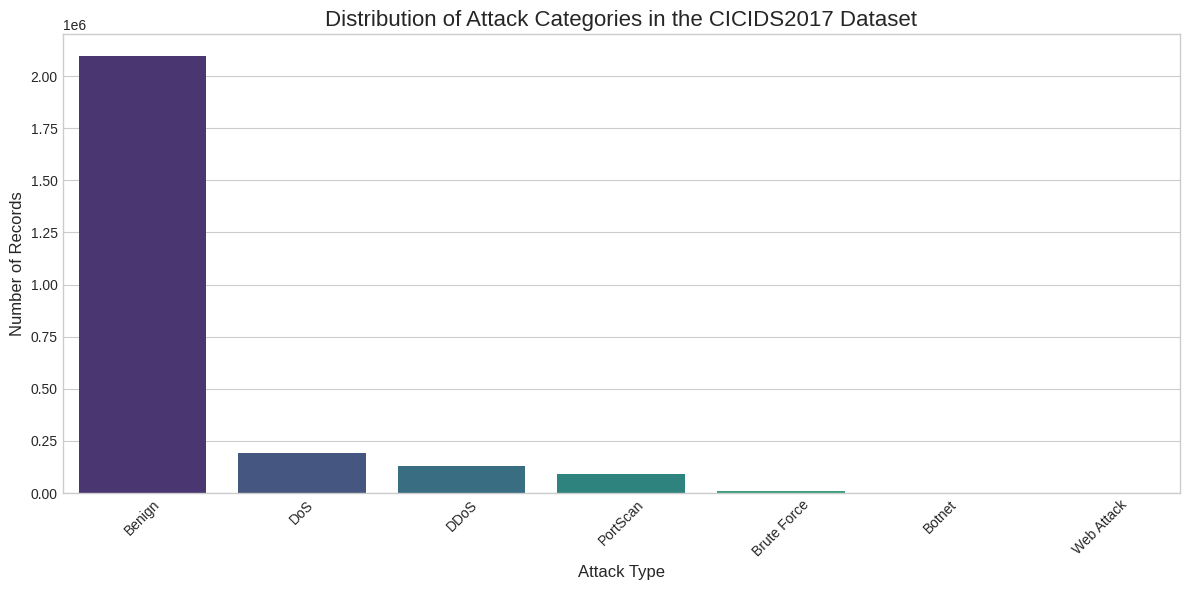

In [ ]:
# ==============================================================================
# VISUALIZATION 1: ATTACK CATEGORY DISTRIBUTION
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Attack Category Distribution plot...")

# Set the style and size for the plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))

# We need the actual names of the labels, not the encoded numbers (0, 1, 2...)
# We can get these from the label_encoder we created.
# The `inverse_transform` converts the numbers back to their original text labels.
attack_labels = label_encoder.inverse_transform(data['Attack Type'])

# Create the count plot
sns.countplot(x=attack_labels, order=pd.Series(attack_labels).value_counts().index, palette='viridis')

plt.title('Distribution of Attack Categories in the CICIDS2017 Dataset', fontsize=16)
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks(rotation=45) # Rotate labels to prevent overlap
plt.tight_layout() # Adjust layout to make sure everything fits

# Save the figure to your Google Drive to include in your report
# Make sure the output_path variable is defined as in the previous script
plt.savefig(os.path.join(output_path, 'attack_distribution.png'))

plt.show()


Finding and plotting the most highly correlated features...


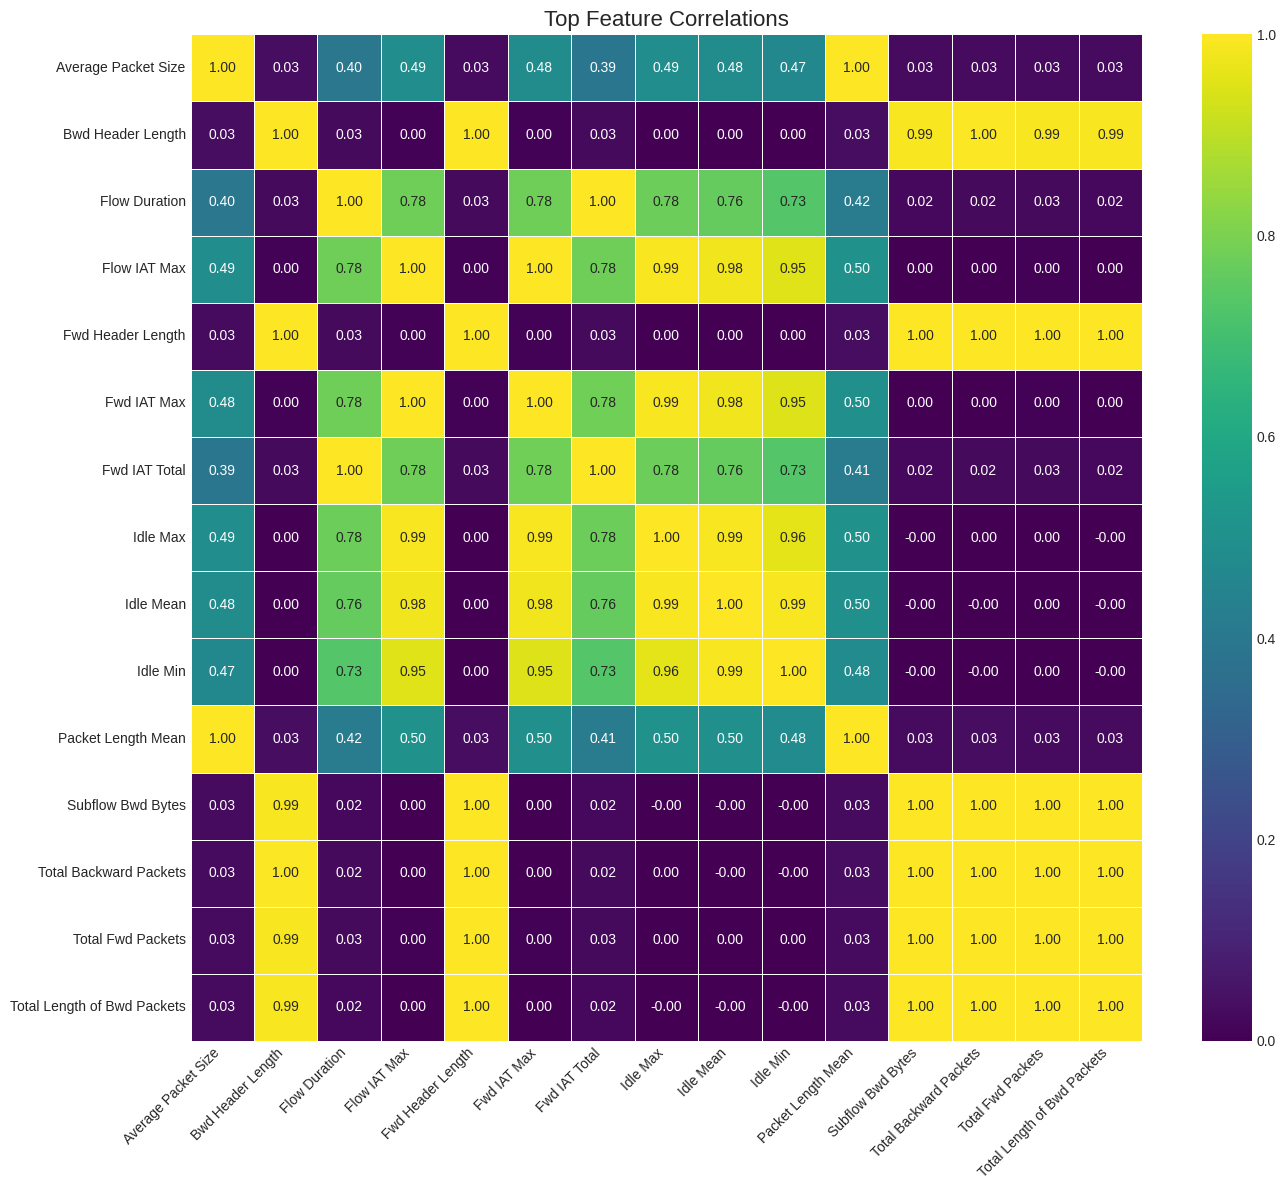

In [ ]:
# ==============================================================================
# VISUALIZATION 2 (CORRECTED METHOD): TOP CORRELATIONS HEATMAP
# ==============================================================================
print("\nFinding and plotting the most highly correlated features...")

# --- Create a sample to avoid memory errors ---
if 'sample_df' not in locals():
    if len(data) > 100000:
        sample_df = data.sample(n=100000, random_state=42)
    else:
        sample_df = data

# --- Calculate Top Correlations (same as before) ---
corr_matrix = sample_df.corr(numeric_only=True).abs()
sol = corr_matrix.unstack()
sol = sol.sort_values(kind="quicksort", ascending=False)
sol = sol[sol != 1.0]
top_pairs = sol.head(40)
top_features = np.unique(top_pairs.index.get_level_values(0).union(top_pairs.index.get_level_values(1)))
top_corr_matrix = sample_df[top_features].corr()

# ==========================================================
# --- PLOTTING FIX STARTS HERE ---
# ==========================================================

# --- 1. Create figure and axes objects for better control ---
fig, ax = plt.subplots(figsize=(14, 12)) # A slightly larger figure size also helps

# --- 2. Draw the heatmap on the created axes ---
sns.heatmap(top_corr_matrix, cmap='viridis', annot=True, fmt='.2f', linewidths=.5, ax=ax)

# --- 3. Set title and rotate ticks (same as before) ---
ax.set_title('Top Feature Correlations', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# --- 4. Apply tight_layout() to the figure object ---
# This is the key step to prevent labels from being cut off
fig.tight_layout()

# --- 5. Save the figure (same as before) ---
plt.savefig(os.path.join(output_path, 'top_correlations_heatmap.png'), dpi=300)

plt.show()